### 10 - SVM no conjunto Wine

Exercício: treine um classificador SVM no conjunto de dados Wine, que pode ser carregado com `sklearn.datasets.load_wine()`. Esse conjunto contém a análise química de 178 amostras de vinho produzidas por 3 cultivadores diferentes. O objetivo é treinar um modelo de classificação capaz de prever o cultivador com base na análise química do vinho. Como classificadores SVM são classificadores binários, será necessário usar one-versus-all para classificar as 3 classes. Qual acurácia você consegue alcançar?


#### Imports


In [1]:
import sys
from packaging import version

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
from sklearn.datasets import load_wine
from sklearn.decomposition import PCA
from sklearn.linear_model import SGDClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC, SVC

assert sys.version_info >= (3, 7)
assert version.parse(sklearn.__version__) >= version.parse("1.0.1")

np.random.seed(42)


#### Carregamento dos dados


In [2]:
wine = load_wine(as_frame=True)

X = wine.data.values
y = wine.target.values


In [3]:
print(f"Formato de X: {X.shape}")
print(f"Formato de y: {y.shape}")
print(f"Classes: {wine.target_names}")

wine.frame.head()


Formato de X: (178, 13)
Formato de y: (178,)
Classes: ['class_0' 'class_1' 'class_2']


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


#### Modelos

Como SVMs são sensíveis à escala dos atributos, cada modelo fica dentro de um `Pipeline` com `StandardScaler`.


In [4]:
C = 5
m = len(X)


In [5]:
linear_svc = make_pipeline(
    StandardScaler(),
    LinearSVC(C=C, loss="hinge", dual=True, random_state=42, max_iter=100_000),
)


In [6]:
svc = make_pipeline(
    StandardScaler(),
    SVC(kernel="linear", C=C),
)


In [7]:
sgd_clf = make_pipeline(
    StandardScaler(),
    SGDClassifier(
        loss="hinge",
        alpha=1 / (C * m),
        learning_rate="constant",
        eta0=0.001,
        max_iter=100_000,
        tol=1e-6,
        random_state=42,
    ),
)


In [8]:
models = {
    "LinearSVC": linear_svc,
    "SVC(kernel='linear')": svc,
    "SGDClassifier": sgd_clf,
}


#### Treinamento


In [9]:
for model in models.values():
    model.fit(X, y)


#### Avaliação


In [10]:
rows = []

for name, model in models.items():
    rows.append({"modelo": name, "acuracia": model.score(X, y)})

evaluation = pd.DataFrame(rows).set_index("modelo")
evaluation.sort_values("acuracia", ascending=False).round(4)


,acuracia
modelo,
LinearSVC,1.0
SVC(kernel='linear'),1.0
SGDClassifier,1.0


#### Preparação para o gráfico

O Wine tem 13 atributos, então não conseguimos desenhar diretamente a fronteira de decisão. Para visualizar, projetamos os dados em 2 dimensões com PCA. O gráfico abaixo serve apenas para interpretação visual; a avaliação acima usa os 13 atributos originais.


In [11]:
pca = make_pipeline(
    StandardScaler(),
    PCA(n_components=2, random_state=42),
)

X_pca = pca.fit_transform(X)


In [12]:
visual_models = {
    "LinearSVC": make_pipeline(
        StandardScaler(),
        LinearSVC(C=C, loss="hinge", dual=True, random_state=42, max_iter=100_000),
    ),
    "SVC(kernel='linear')": make_pipeline(
        StandardScaler(),
        SVC(kernel="linear", C=C),
    ),
    "SGDClassifier": make_pipeline(
        StandardScaler(),
        SGDClassifier(
            loss="hinge",
            alpha=1 / (C * len(X_pca)),
            learning_rate="constant",
            eta0=0.001,
            max_iter=100_000,
            tol=1e-6,
            random_state=42,
        ),
    ),
}

for model in visual_models.values():
    model.fit(X_pca, y)


In [13]:
# A malha representa vários pontos do plano PCA; o modelo prediz uma classe
# para cada ponto, permitindo colorir regiões e desenhar fronteiras de decisão.
padding = 0.8
x_min, x_max = X_pca[:, 0].min() - padding, X_pca[:, 0].max() + padding
y_min, y_max = X_pca[:, 1].min() - padding, X_pca[:, 1].max() + padding

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 500),
    np.linspace(y_min, y_max, 500),
)

grid = np.c_[xx.ravel(), yy.ravel()]


#### Fronteiras de decisão


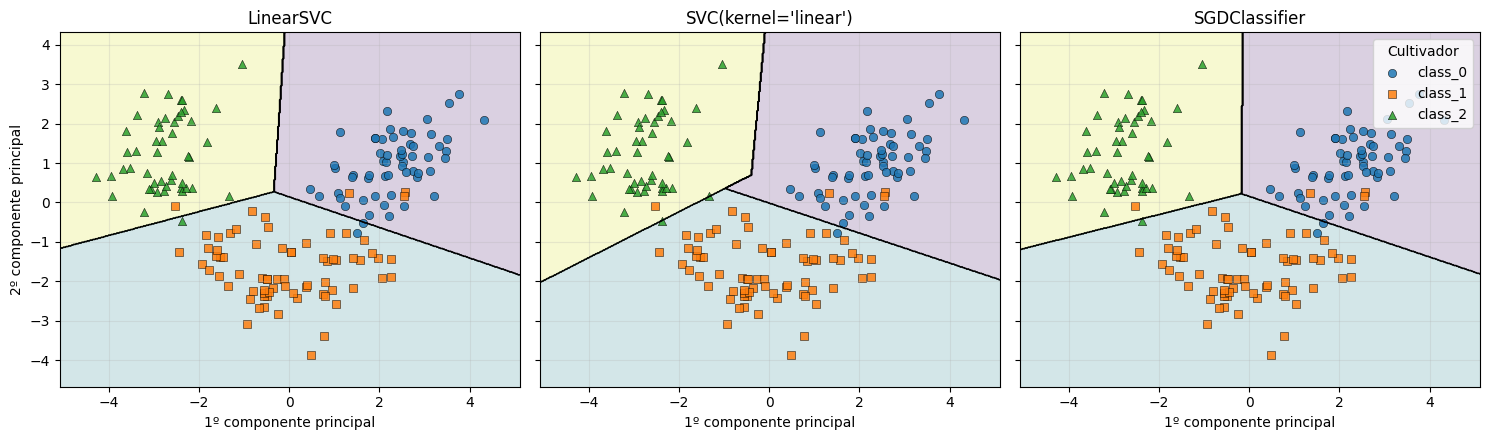

In [14]:
markers = ["o", "s", "^"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharex=True, sharey=True)

for ax, (name, model) in zip(axes, visual_models.items()):
    Z = model.predict(grid).reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.2, cmap="viridis")
    ax.contour(xx, yy, Z, colors="black", linewidths=0.8, alpha=0.7)

    for class_id, class_name, marker in zip([0, 1, 2], wine.target_names, markers):
        ax.scatter(
            X_pca[y == class_id, 0],
            X_pca[y == class_id, 1],
            label=class_name,
            marker=marker,
            edgecolor="black",
            linewidth=0.4,
            alpha=0.85,
        )

    ax.set_title(name)
    ax.set_xlabel("1º componente principal")
    ax.grid(True, alpha=0.25)

axes[0].set_ylabel("2º componente principal")
axes[-1].legend(title="Cultivador", loc="upper right")
plt.tight_layout()
plt.show()


Os três estimadores conseguem lidar com o problema multiclasse usando one-versus-all internamente. Neste conjunto, os modelos lineares já alcançam acurácia alta depois do escalonamento dos atributos.
